# PCA Implementation Example

This notebook demonstrates how to use the custom `rice_ml` PCA implementation and visualize the transformed data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from rice_ml.Unsupervised_Learning.pca import PCA 

from rice_ml.processing.preprocessing import train_test_split, standardize

from sklearn.datasets import make_blobs

# Set the Seaborn theme
sns.set_theme()

/Users/ccarr21/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# Create, Scale, and Explore 3D Data

Original Data Shape: (1000, 3)
Standardized Data Shape: (1000, 3)


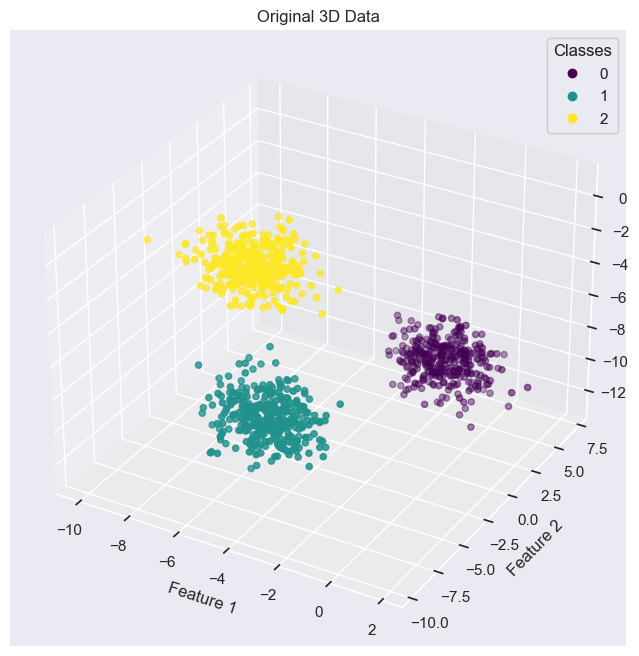

In [4]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=3, random_state=1)

# Standardize the data
X_scaled = standardize(X)

print(f"Original Data Shape: {X.shape}")
print(f"Standardized Data Shape: {X_scaled.shape}")

# Plot the original data
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') 
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', s=20)

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

plt.title("Original 3D Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Training, Testing, and Fitting the PCA Model

Variance Analysis: [0.73234953 0.21563115]


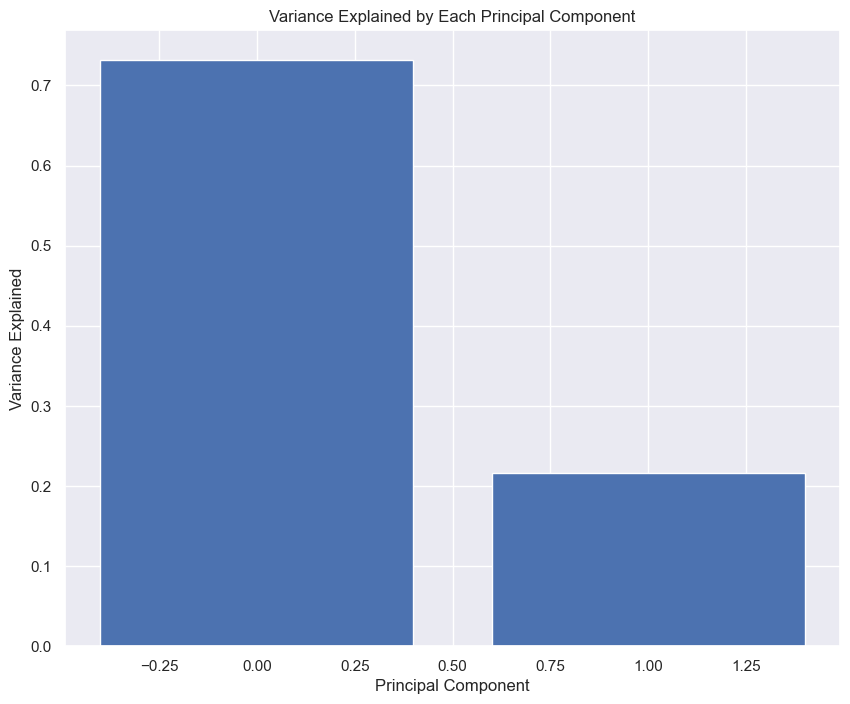

In [11]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize the PCA model
pca = PCA(n_components=2)

# Fit the PCA model
pca_model = pca.fit(X_train)

# Transform the data
X_pca = pca.transform(X_train)

# Variance Analysis
print(f"Variance Analysis: {pca.explained_variance_ratio_}")

# Plot the variance explained by each principal component
plt.figure(figsize=(10, 8))
plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
plt.title("Variance Explained by Each Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.show()

# Visualization and Evaluation

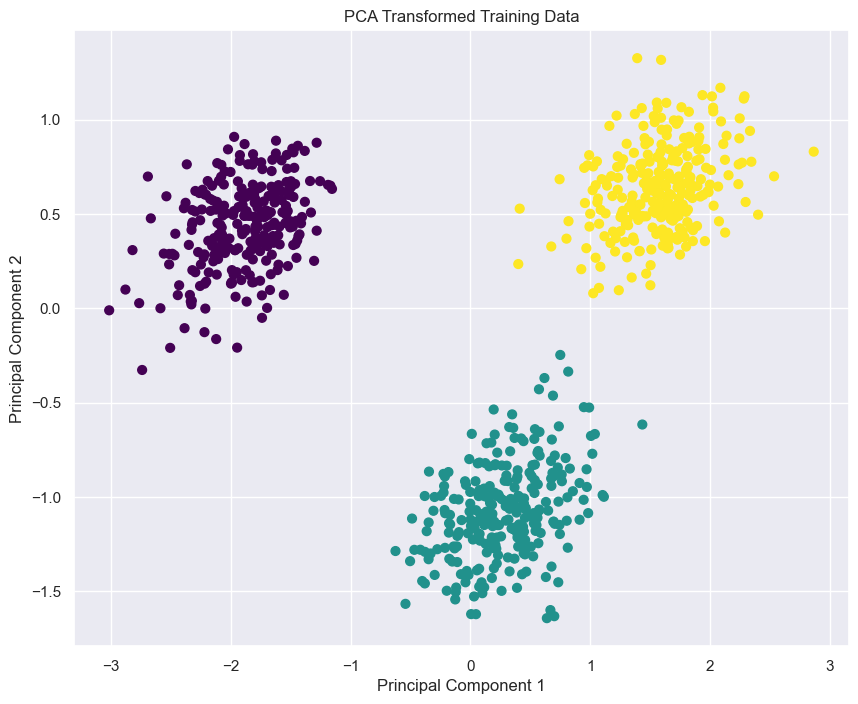

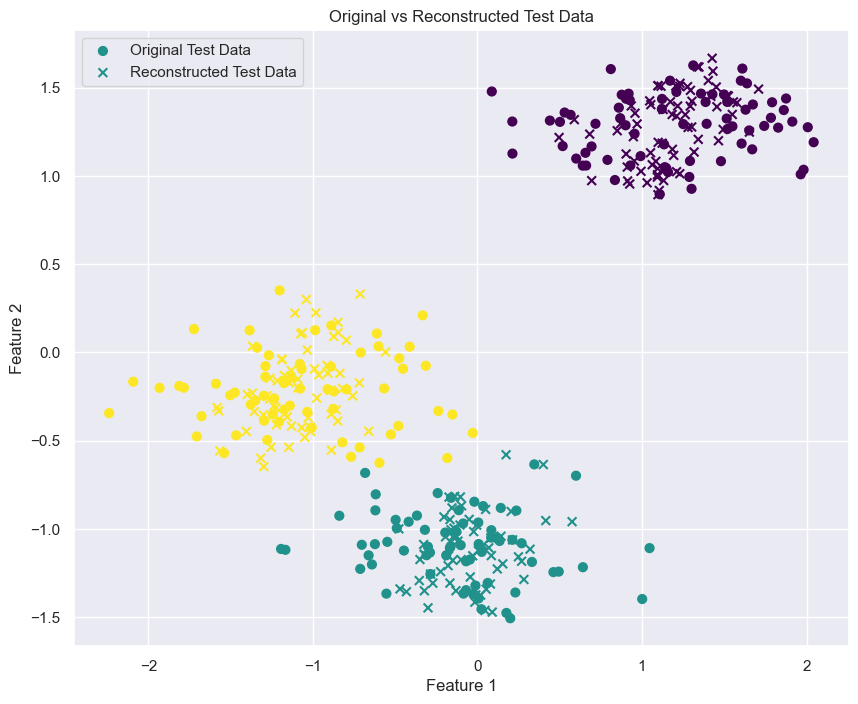

In [18]:
# Fit PCA on train, transform train and test
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Plot transformed training data
plt.figure(figsize=(10, 8))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="viridis", s=40)
plt.title("PCA Transformed Training Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Reconstruct test data from test PCA projection
X_test_reconstructed = pca.inverse_transform(X_test_pca)

# Plot original vs reconstructed (first two original features)
plt.figure(figsize=(10, 8))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="viridis", s=40, label="Original Test Data")
plt.scatter(
    X_test_reconstructed[:, 0],
    X_test_reconstructed[:, 1],
    c=y_test,
    cmap="viridis",
    s=40,
    marker="x",
    label="Reconstructed Test Data",
)
plt.legend()
plt.title("Original vs Reconstructed Test Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()